In [20]:
!pip install openpyxl
!pip install shap

In [21]:
import os
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# Scikit-Learn Framework Components
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Suppress warnings for clean notebook execution output
warnings.filterwarnings('ignore')

In [22]:
# 1. Unzip the data programmatically
zip_path = "data/Telco_customer_churn.zip"
extract_dir = "data/"

if os.path.exists(zip_path):
    print("Extracting raw dataset zip file...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete. Excel file is ready inside the data/ folder.\n")
else:
    print("Notification: Zip file not found or already extracted. Searching for data files...")

# 2. Load the Excel file into a Pandas DataFrame
# Updated path and function to handle the .xlsx extension discovered in the directory
raw_excel_path = "data/Telco_customer_churn.xlsx"

try:
    df = pd.read_excel(raw_excel_path, engine='openpyxl')
    print(f"Dataset successfully loaded! Shape: {df.shape} (7,043 customers, 33 columns)")
except Exception as e:
    print(f"Error loading Excel file: {str(e)}")

# 3. Interview Prep: Fix the 'Total Charges' hidden data type bug
if 'Total Charges' in df.columns:
    df['Total Charges'] = df['Total Charges'].replace(" ", pd.NA)
    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
    df['Total Charges'] = df['Total Charges'].fillna(0)
    print("Sanitized 'Total Charges' data type and handled hidden empty spaces.")

# 4. Interview Prep: Eliminate target leakage
cols_to_drop = [
    'CustomerID', 'Count', 'Country', 'State', 
    'Churn Label', 'Churn Score', 'Churn Reason'
]
existing_drops = [col for col in cols_to_drop if col in df.columns]
df_cleaned = df.drop(columns=existing_drops)
print(f"Dropped {len(existing_drops)} administrative/leaky columns.")

# 5. Stratified Train/Test Split
X = df_cleaned.drop(columns=['Churn Value'])
y = df_cleaned['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData Isolation Pipeline Results:")
print(f"└── Training Features: {X_train.shape} (80% of data for training)")
print(f"└── Testing Features:  {X_test.shape} (20% isolated data for evaluation)")
print(f"└── Churn Rate in Training Set: {(y_train.value_counts(normalize=True)[1])*100:.2f}%")

Extracting raw dataset zip file...
Extraction complete. Excel file is ready inside the data/ folder.

Dataset successfully loaded! Shape: (7043, 33) (7,043 customers, 33 columns)
Sanitized 'Total Charges' data type and handled hidden empty spaces.
Dropped 7 administrative/leaky columns.

Data Isolation Pipeline Results:
└── Training Features: (5634, 25) (80% of data for training)
└── Testing Features:  (1409, 25) (20% isolated data for evaluation)
└── Churn Rate in Training Set: 26.54%


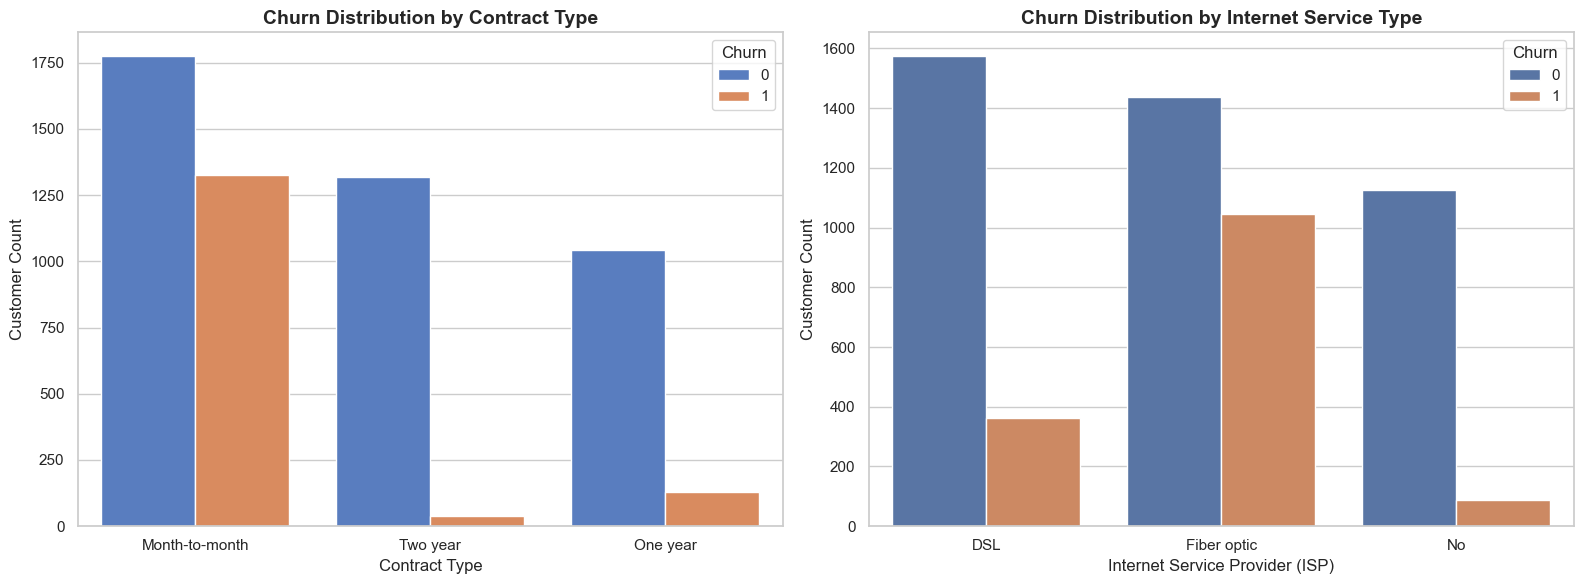

--- Exact Business Metrics ---

Churn Rate by Contract Type:
└── Month-to-month: 42.75%
└── One year: 11.08%
└── Two year: 2.87%

Churn Rate by Internet Service Type:
└── DSL: 18.69%
└── Fiber optic: 42.09%
└── No: 7.25%


In [23]:
# 1. Combine training features and target for visualization purposes
analysis_df = X_train.copy()
analysis_df['Churn'] = y_train

# Set up the plotting aesthetics for a professional look
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Contract Type vs Churn
# Hypothesis: Customers on short-term contracts are highly volatile.
sns.countplot(
    data=analysis_df, 
    x='Contract', 
    hue='Churn', 
    ax=axes[0], 
    palette='muted'
)
axes[0].set_title('Churn Distribution by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Customer Count')

# Plot 2: Internet Service vs Churn
# Hypothesis: Technical issues or pricing in specific network types drive churn.
sns.countplot(
    data=analysis_df, 
    x='Internet Service', 
    hue='Churn', 
    ax=axes[1], 
    palette='deep'
)
axes[1].set_title('Churn Distribution by Internet Service Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Internet Service Provider (ISP)')
axes[1].set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

# 2. Calculate exact percentages to back up the visual narrative
print("--- Exact Business Metrics ---")
contract_churn = analysis_df.groupby('Contract')['Churn'].mean() * 100
internet_churn = analysis_df.groupby('Internet Service')['Churn'].mean() * 100

print("\nChurn Rate by Contract Type:")
for contract, rate in contract_churn.items():
    print(f"└── {contract}: {rate:.2f}%")

print("\nChurn Rate by Internet Service Type:")
for provider, rate in internet_churn.items():
    print(f"└── {provider}: {rate:.2f}%")

In [24]:
print(X_train.columns.tolist())


['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


In [25]:
# 1. Define numerical features, explicitly moving CLTV here
numeric_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Latitude', 'Longitude', 'CLTV']

# 2. Explicitly define valid, low-cardinality categorical features
categorical_features = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 
    'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 
    'Contract', 'Paperless Billing', 'Payment Method'
]

print("Preprocessing Configuration:")
print(f"├── Scaling numerical columns: {numeric_features}")
print(f"└── Encoding categorical columns: {categorical_features}\n")

# 3. Construct the Preprocessing Transformer Pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 4. Execute the pipeline transformations
print("Executing production data preprocessing pipeline...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nFinal Transformation Summary:")
print(f"├── Raw input training features shape: {X_train.shape}")
print(f"└── Production engineered matrix shape for ML model: {X_train_processed.shape}")

Preprocessing Configuration:
├── Scaling numerical columns: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Latitude', 'Longitude', 'CLTV']
└── Encoding categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Executing production data preprocessing pipeline...

Final Transformation Summary:
├── Raw input training features shape: (5634, 25)
└── Production engineered matrix shape for ML model: (5634, 33)


In [26]:
# 1. INITIALIZE THE CLASS_WEIGHT BALANCED MODELS
# We set class_weight='balanced' to force the models to penalize mistakes on the minority churn class
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. TRAIN BOTH MODELS ON THE PROCESSED TRAINING MATRIX
print("Training Logistic Regression baseline...")
log_reg.fit(X_train_processed, y_train)

print("Training Random Forest ensemble...")
rf_clf.fit(X_train_processed, y_train)
print("Model training complete.\n")

# 3. GENERATE PREDICTIONS ON THE ISOLATED TEST MATRIX
y_pred_log = log_reg.predict(X_test_processed)
y_pred_rf = rf_clf.predict(X_test_processed)

# 4. PRINT COMPREHENSIVE PERFORMANCE REPORTS
print("=================== LOGISTIC REGRESSION REPORT ===================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_log):.2f}")
print(classification_report(y_test, y_pred_log, target_names=['Stayed (0)', 'Churned (1)']))

print("\n===================== RANDOM FOREST REPORT =====================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed (0)', 'Churned (1)']))

Training Logistic Regression baseline...
Training Random Forest ensemble...
Model training complete.

=================== LOGISTIC REGRESSION REPORT ===================
Overall Accuracy: 0.75
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.73      0.81      1035
 Churned (1)       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409


===================== RANDOM FOREST REPORT =====================
Overall Accuracy: 0.80
              precision    recall  f1-score   support

  Stayed (0)       0.84      0.91      0.87      1035
 Churned (1)       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



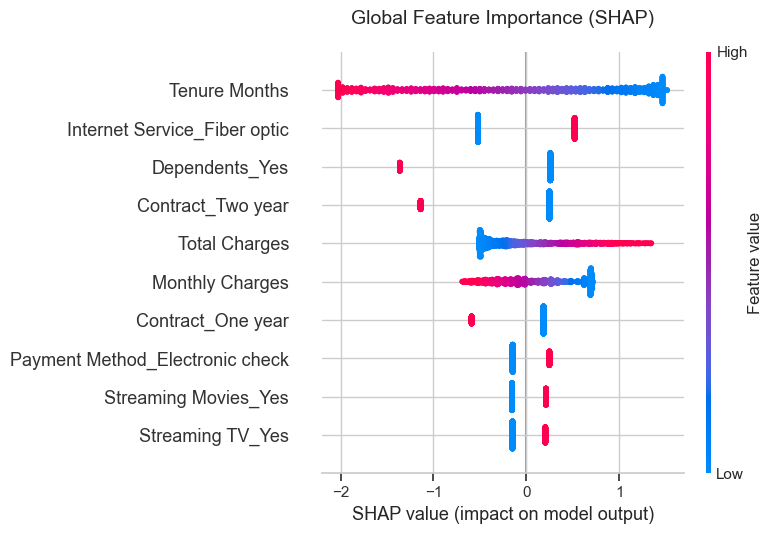

In [30]:
# 1. RECONSTRUCT FEATURE NAMES FOR EXPLAINABILITY
# When we one-hot encoded our features, scikit-learn created new columns.
# We extract those names to make our plots readable.
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + encoded_cat_features

# 2. INITIALIZE SHAP LINEAR EXPLAINER
# Explicitly sample 100 background rows to optimize execution speed and suppress warnings
X_train_summary = shap.utils.sample(X_train_processed, 100, random_state=42)

explainer = shap.LinearExplainer(
    log_reg, 
    X_train_summary, 
    feature_perturbation="interventional"
)
shap_values = explainer(X_test_processed)

# Assign the clear feature names to the summary object
shap_values.feature_names = all_feature_names

# 3. GENERATE THE SUMMARY PLOT
plt.title("Global Feature Importance (SHAP)", fontsize=14, pad=20)
shap.summary_plot(shap_values, X_test_processed, feature_names=all_feature_names, max_display=10, show=False)
plt.tight_layout()
plt.show()

In [31]:


# Save the trained preprocessor pipeline, model instance, and correct feature names
with open("data/churn_model.pkl", "wb") as f:
    pickle.dump((preprocessor, log_reg, all_feature_names), f)

print("Model artifacts successfully saved to data/churn_model.pkl")

Model artifacts successfully saved to data/churn_model.pkl


In [32]:
%%writefile app.py


st.set_page_config(page_title="Customer Churn Intelligence Platform", layout="wide")

# 1. LOAD SERIALIZED MODEL ARTIFACTS
@st.cache_resource
def load_model():
    with open("data/churn_model.pkl", "rb") as f:
        preprocessor, model, feature_names = pickle.load(f)
    return preprocessor, model, feature_names

try:
    preprocessor, model, feature_names = load_model()
except FileNotFoundError:
    st.error("Error: Model files not found. Please ensure data/churn_model.pkl exists.")
    st.stop()

# 2. WEB APP LAYOUT
st.title("📊 Customer Churn Intelligence Platform")
st.markdown("An enterprise-grade optimization tool designed to analyze customer risk metrics and protect contract revenue streams.")
st.markdown("---")

# 3. INTERACTIVE SIDEBAR FOR CUSTOMER PROFILE INPUT
st.sidebar.header("Customer Profile Input")

gender = st.sidebar.selectbox("Gender", ["Male", "Female"])
senior_citizen = st.sidebar.selectbox("Senior Citizen", ["No", "Yes"])
partner = st.sidebar.selectbox("Partner", ["No", "Yes"])
dependents = st.sidebar.selectbox("Dependents", ["No", "Yes"])
phone_service = st.sidebar.selectbox("Phone Service", ["No", "Yes"])
multiple_lines = st.sidebar.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])
internet_service = st.sidebar.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
online_security = st.sidebar.selectbox("Online Security", ["No", "Yes", "No internet service"])
online_backup = st.sidebar.selectbox("Online Backup", ["No", "Yes", "No internet service"])
device_protection = st.sidebar.selectbox("Device Protection", ["No", "Yes", "No internet service"])
tech_support = st.sidebar.selectbox("Tech Support", ["No", "Yes", "No internet service"])
streaming_tv = st.sidebar.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
streaming_movies = st.sidebar.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])
contract = st.sidebar.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
paperless_billing = st.sidebar.selectbox("Paperless Billing", ["No", "Yes"])
payment_method = st.sidebar.selectbox("Payment Method", [
    "Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"
])

tenure = st.sidebar.slider("Tenure (Months)", 0, 72, 12)
monthly_charges = st.sidebar.slider("Monthly Charges ($)", 18.0, 120.0, 65.0)
cltv = st.sidebar.slider("Customer Lifetime Value (CLTV)", 2000, 6500, 3500)

# Static geographic midpoints for runtime validation
latitude = 34.0522
longitude = -118.2437
total_charges = tenure * monthly_charges

# 4. CONSTRUCT DATAFRAME MATCHING ORIGINAL TRAINING SCHEMA
input_data = pd.DataFrame([{
    'City': 'Los Angeles', 'Zip Code': 90001, 'Lat Long': '34.0522, -118.2437',
    'Latitude': latitude, 'Longitude': longitude, 'Gender': gender, 
    'Senior Citizen': senior_citizen, 'Partner': partner, 'Dependents': dependents, 
    'Tenure Months': tenure, 'Phone Service': phone_service, 'Multiple Lines': multiple_lines, 
    'Internet Service': internet_service, 'Online Security': online_security, 'Online Backup': online_backup, 
    'Device Protection': device_protection, 'Tech Support': tech_support, 'Streaming TV': streaming_tv, 
    'Streaming Movies': streaming_movies, 'Contract': contract, 'Paperless Billing': paperless_billing, 
    'Payment Method': payment_method, 'Monthly Charges': monthly_charges, 'Total Charges': total_charges, 
    'CLTV': cltv
}])

# 5. EXECUTE PIPELINE TRANSFORMATIONS & LIVE INFERENCE
processed_input = preprocessor.transform(input_data)
risk_probability = model.predict_proba(processed_input)[0][1]
prediction = model.predict(processed_input)[0]

# 6. RENDER ANALYSIS DASHBOARD
col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("Risk Inference Output")
    metric_color = "red" if risk_probability > 0.5 else "green"
    st.markdown(f"### Attrition Risk Score: <span style='color:{metric_color}'>{risk_probability*100:.2f}%</span>", unsafe_allow_html=True)
    
    if prediction == 1:
        st.error(" HIGH RISK ACTION REQUIRED: This customer exhibits behavioral attributes heavily correlated with near-term cancellation.")
    else:
        st.success("STABLE ACCOUNT: This customer profile tracks closely with historical baseline customer retention.")

with col2:
    st.subheader("Financial Impact Assessment")
    estimated_loss = cltv if prediction == 1 else 0.0
    st.metric(label="At-Risk Revenue Value (CLTV)", value=f"${cltv:,.2f}", delta=f"${estimated_loss:,.2f}" if prediction == 1 else "$0.00", delta_color="inverse")
    st.caption("Financial prioritization matrix: Flag accounts where high risk score intersects with top-tier CLTV values.")


Overwriting app.py
